# 📊 Saiket Systems — Customer Churn Analysis & Prediction
**Intern:** Sonu Kumar  
**Duration:** 17/03/2026 to 17/04/2026  
**Dataset:** Telco Customer Churn Dataset  

---
## Tasks Covered:
- ✅ Task 1: Data Loading & Preprocessing
- ✅ Task 2: Exploratory Data Analysis (EDA)
- ✅ Task 3: Customer Segmentation
- ✅ Task 4: Churn Prediction Model
- ✅ Task 5: Model Evaluation
- ✅ Task 6: Business Recommendations

---
# 🔵 TASK 1: Data Loading & Preprocessing

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset  (3).csv to Telco_Customer_Churn_Dataset  (3) (1).csv


In [ ]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
# --- Load Dataset ---
# If running on Google Colab, upload the CSV file first
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("Telco_Customer_Churn_Dataset  (3).csv")

print('✅ Dataset Loaded Successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

✅ Dataset Loaded Successfully!
Shape: 7043 rows × 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# --- Basic Dataset Info ---
print('=== DATASET INFO ===')
print(df.info())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
# --- Check Missing Values ---
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print('\n✅ No columns with > 0 missing values shown above means dataset is clean!')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✅ No columns with > 0 missing values shown above means dataset is clean!


In [ ]:
# --- Preprocessing ---

# 1. Fix TotalCharges column (it has spaces which prevent numeric conversion)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Fill NaN values in TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3. Drop customerID (not useful for modeling)
df_model = df.drop('customerID', axis=1)

# 4. Encode target variable: Churn -> 1 (Yes), 0 (No)
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# 5. Label Encode all categorical columns
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('✅ Preprocessing Complete!')
print(f'Categorical columns encoded: {categorical_cols}')
print(f'\nFinal dataset shape: {df_model.shape}')
df_model.head()

✅ Preprocessing Complete!
Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
# --- Statistical Summary ---
print('=== STATISTICAL SUMMARY ===')
df.describe()

=== STATISTICAL SUMMARY ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


---
# 🟣 TASK 2: Exploratory Data Analysis (EDA)

=== OVERALL CHURN RATE ===
Not Churned (No): 5174 customers (73.5%)
Churned (Yes):    1869 customers (26.5%)


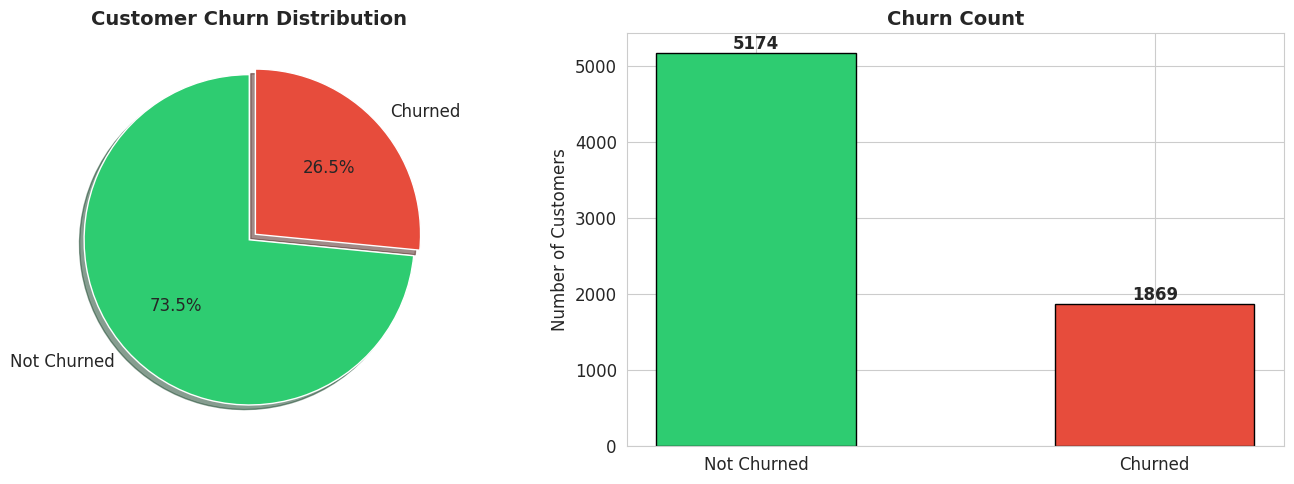


📌 Insight: ~26% customers have churned — this is a significant business concern.


In [ ]:
# --- Overall Churn Rate ---
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== OVERALL CHURN RATE ===')
print(f"Not Churned (No): {churn_counts['No']} customers ({churn_pct['No']:.1f}%)")
print(f"Churned (Yes):    {churn_counts['Yes']} customers ({churn_pct['Yes']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Not Churned', 'Churned'], churn_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: ~26% customers have churned — this is a significant business concern.')

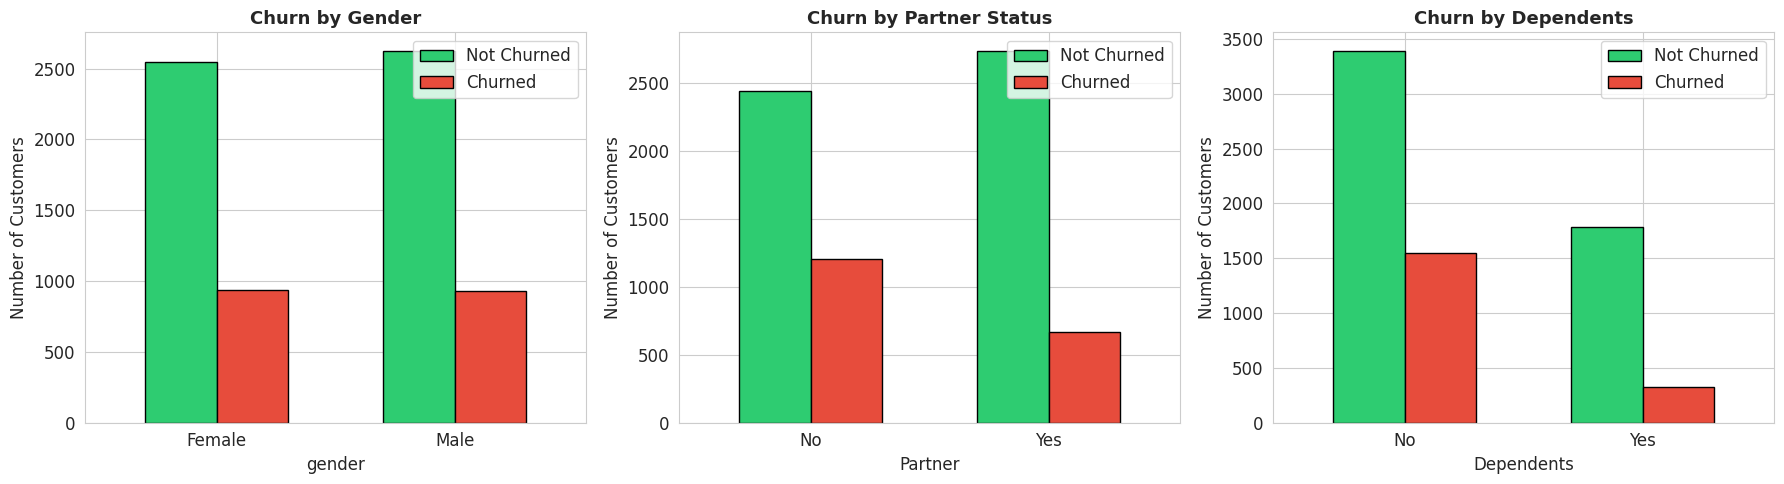

Churn Rate by Gender (%):
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64

Churn Rate by Partner (%):
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64

Churn Rate by Dependents (%):
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64


In [ ]:
# --- Churn by Gender, Partner, Dependents ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cat_features = ['gender', 'Partner', 'Dependents']
titles = ['Churn by Gender', 'Churn by Partner Status', 'Churn by Dependents']
colors_map = {'No': '#2ecc71', 'Yes': '#e74c3c'}

for ax, feat, title in zip(axes, cat_features, titles):
    churn_data = df.groupby([feat, 'Churn']).size().unstack(fill_value=0)
    churn_data.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', width=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Number of Customers')
    ax.legend(['Not Churned', 'Churned'])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insights
gender_churn = df.groupby('gender')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
partner_churn = df.groupby('Partner')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
dep_churn = df.groupby('Dependents')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
print('Churn Rate by Gender (%):')
print(gender_churn.round(1))
print('\nChurn Rate by Partner (%):')
print(partner_churn.round(1))
print('\nChurn Rate by Dependents (%):')
print(dep_churn.round(1))

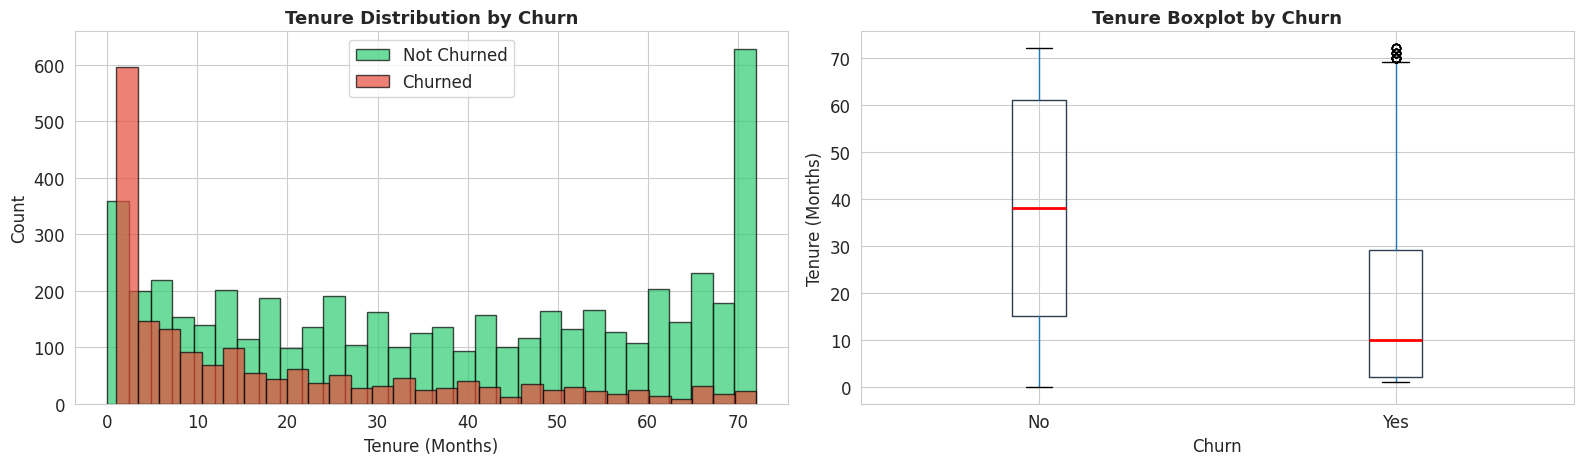

Average tenure - Churned: 18.0 months
Average tenure - Not Churned: 37.6 months

📌 Insight: Customers who churn have much lower tenure — new customers are at higher risk!


In [ ]:
# --- Tenure Distribution & Churn ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of tenure by churn
churned = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

axes[0].hist(not_churned, bins=30, alpha=0.7, color='#2ecc71', label='Not Churned', edgecolor='black')
axes[0].hist(churned, bins=30, alpha=0.7, color='#e74c3c', label='Churned', edgecolor='black')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Tenure Boxplot by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (Months)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tenure - Churned: {churned.mean():.1f} months")
print(f"Average tenure - Not Churned: {not_churned.mean():.1f} months")
print('\n📌 Insight: Customers who churn have much lower tenure — new customers are at higher risk!')

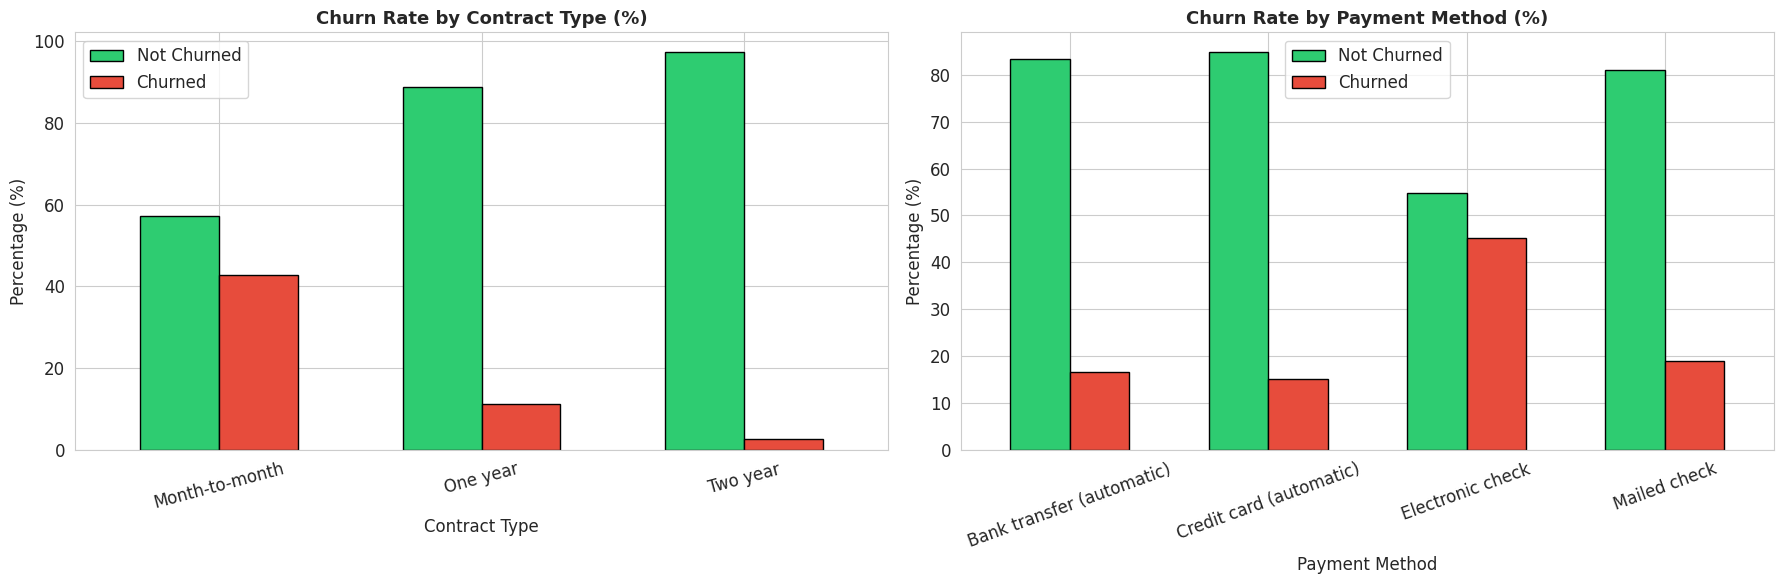

Churn % by Contract Type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Yes, dtype: float64

📌 Insight: Month-to-month contract customers churn the most!


In [ ]:
# --- Churn by Contract Type & Payment Method ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Contract type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_churn_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                         edgecolor='black', width=0.6)
axes[0].set_title('Churn Rate by Contract Type (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Not Churned', 'Churned'])
axes[0].tick_params(axis='x', rotation=15)

# Payment method
pay_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack(fill_value=0)
pay_churn_pct = pay_churn.div(pay_churn.sum(axis=1), axis=0) * 100
pay_churn_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', width=0.6)
axes[1].set_title('Churn Rate by Payment Method (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Not Churned', 'Churned'])
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('contract_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Churn % by Contract Type:')
print(contract_churn_pct['Yes'].round(1))
print('\n📌 Insight: Month-to-month contract customers churn the most!')

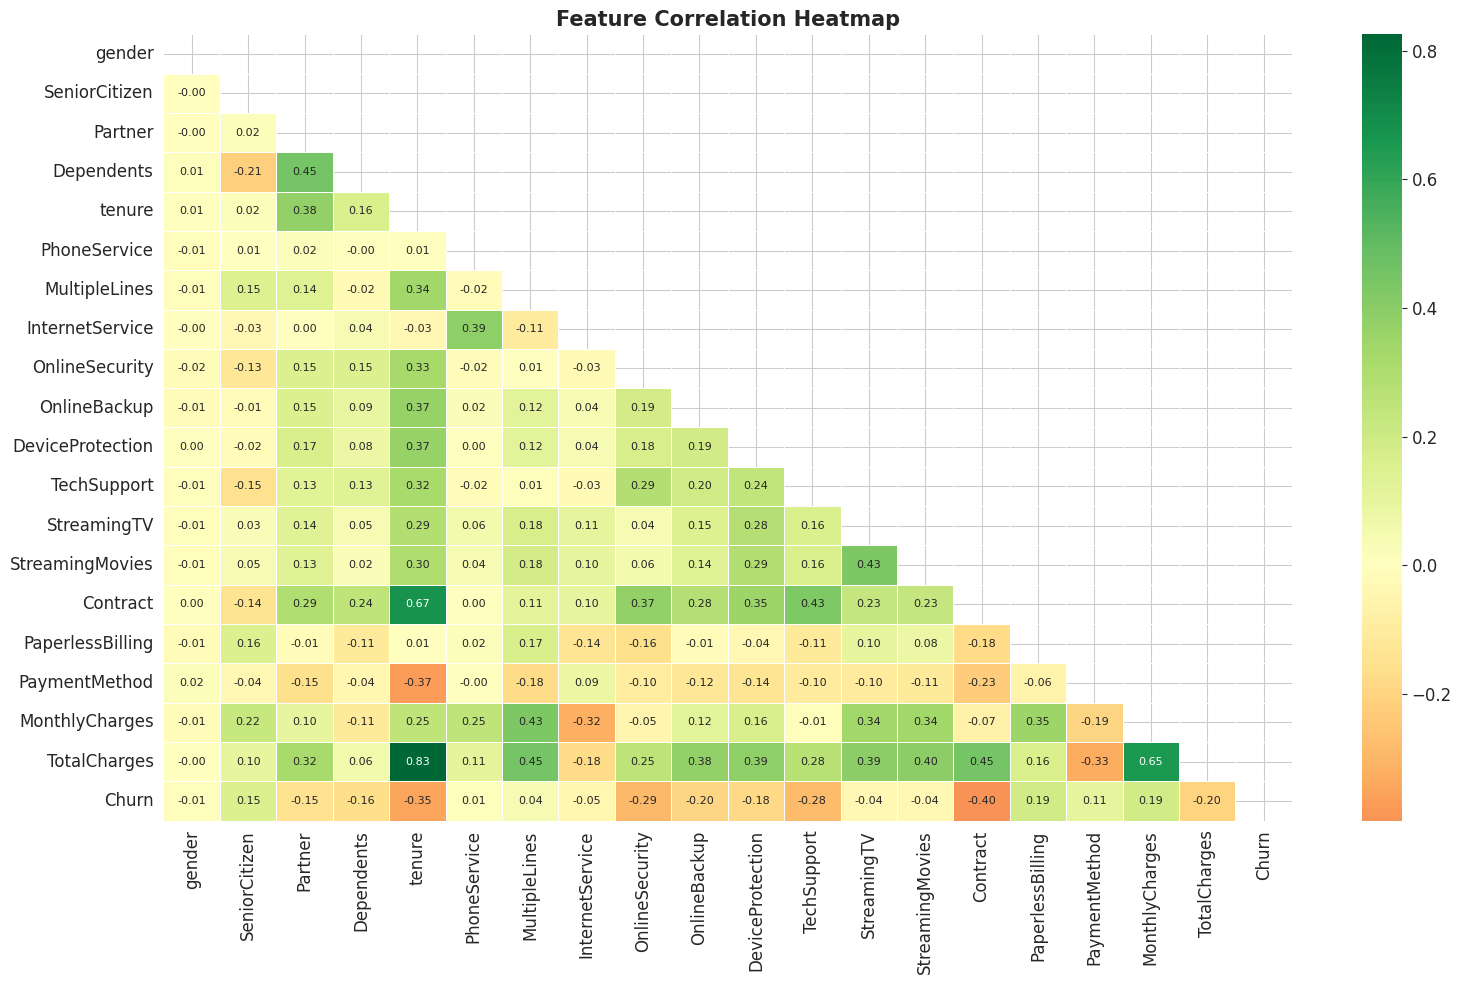


📌 Insight: Tenure has strong negative correlation with Churn — longer tenure = less churn.


In [ ]:
# --- Correlation Heatmap ---
plt.figure(figsize=(16, 10))
corr_matrix = df_model.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Tenure has strong negative correlation with Churn — longer tenure = less churn.')

---
# 🟢 TASK 3: Customer Segmentation

=== CUSTOMER SEGMENTS ===
        Segment  Total_Customers  Churned  Avg_Monthly_Charge  Avg_Tenure  Churn_Rate_%
    Low (₹0-35)             1735      189               22.03        28.7          10.9
Medium (₹35-65)             1409      326               51.85        26.5          23.1
  High (₹65-95)             2604      936               80.76        30.3          35.9
 Premium (₹95+)             1295      418              103.90        47.9          32.3


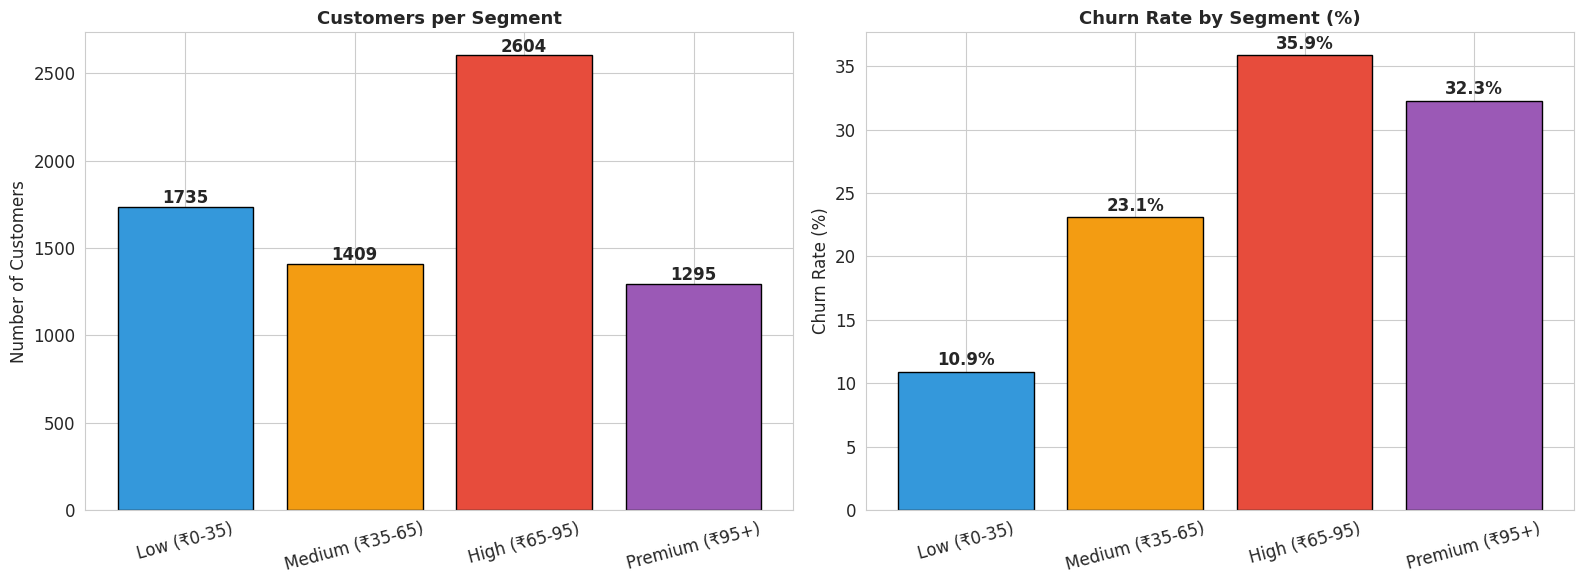


📌 Insight: Premium segment customers pay more AND churn more — needs immediate attention!


In [ ]:
# --- Segment customers by Monthly Charges ---
df['Segment'] = pd.cut(df['MonthlyCharges'],
                        bins=[0, 35, 65, 95, 200],
                        labels=['Low (₹0-35)', 'Medium (₹35-65)',
                                'High (₹65-95)', 'Premium (₹95+)'])

print('=== CUSTOMER SEGMENTS ===')
seg_summary = df.groupby('Segment').agg(
    Total_Customers=('customerID', 'count'),
    Churned=('Churn', lambda x: (x == 'Yes').sum()),
    Avg_Monthly_Charge=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean')
).reset_index()
seg_summary['Churn_Rate_%'] = (seg_summary['Churned'] / seg_summary['Total_Customers'] * 100).round(1)
seg_summary['Avg_Monthly_Charge'] = seg_summary['Avg_Monthly_Charge'].round(2)
seg_summary['Avg_Tenure'] = seg_summary['Avg_Tenure'].round(1)
print(seg_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#3498db', '#f39c12', '#e74c3c', '#9b59b6']

# Total customers per segment
bars = axes[0].bar(seg_summary['Segment'], seg_summary['Total_Customers'],
                   color=colors, edgecolor='black')
for bar, val in zip(bars, seg_summary['Total_Customers']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)

# Churn rate per segment
bars2 = axes[1].bar(seg_summary['Segment'], seg_summary['Churn_Rate_%'],
                    color=colors, edgecolor='black')
for bar, val in zip(bars2, seg_summary['Churn_Rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Segment (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: Premium segment customers pay more AND churn more — needs immediate attention!')

In [ ]:
# --- Identify High-Value Churning Customers ---
high_value_churned = df[(df['MonthlyCharges'] > 65) & (df['Churn'] == 'Yes')]
low_value_churned = df[(df['MonthlyCharges'] <= 65) & (df['Churn'] == 'Yes')]

print(f'High-Value Customers who Churned (MonthlyCharges > $65): {len(high_value_churned)}')
print(f'Low-Value Customers who Churned: {len(low_value_churned)}')
print(f'\nAvg Monthly Charge of Churned High-Value: ${high_value_churned["MonthlyCharges"].mean():.2f}')
print(f'Estimated Monthly Revenue Lost: ${high_value_churned["MonthlyCharges"].sum():.2f}')

High-Value Customers who Churned (MonthlyCharges > $65): 1354
Low-Value Customers who Churned: 515

Avg Monthly Charge of Churned High-Value: $87.51
Estimated Monthly Revenue Lost: $118495.00


---
# 🟡 TASK 4: Churn Prediction Model

In [ ]:
# --- Prepare features and target ---
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size:  {X_train.shape[0]} samples')
print(f'Testing set size:   {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')
print('✅ Train-test split complete!')

Training set size:  5634 samples
Testing set size:   1409 samples
Number of features: 19
✅ Train-test split complete!


In [ ]:
# --- Train Multiple Models ---

# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=6)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print('✅ All 3 models trained successfully!')
print('   1. Logistic Regression')
print('   2. Decision Tree (max_depth=6)')
print('   3. Random Forest (100 trees)')

✅ All 3 models trained successfully!
   1. Logistic Regression
   2. Decision Tree (max_depth=6)
   3. Random Forest (100 trees)


=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     79.91      64.26   54.81     59.16    84.03
Decision Tree           78.42      60.36   54.55     57.30    82.46
Random Forest           79.21      63.73   50.27     56.20    82.25


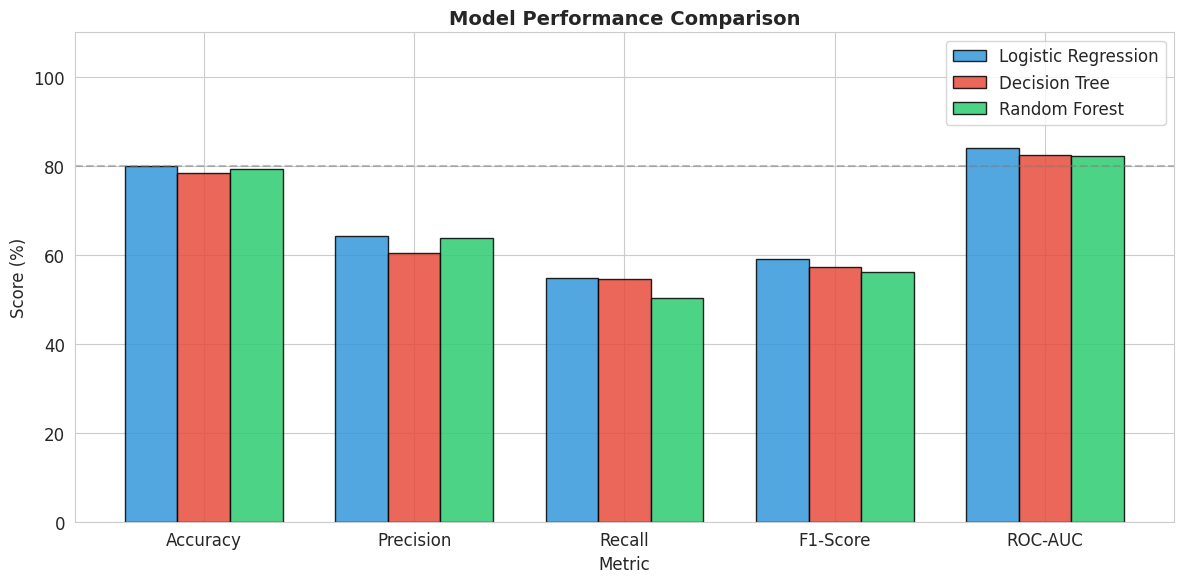

In [ ]:
# --- Compare Model Performance ---
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob) * 100, 2)
    }

results = {
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_prob),
    'Decision Tree':       get_metrics(y_test, dt_pred, dt_prob),
    'Random Forest':       get_metrics(y_test, rf_pred, rf_prob)
}

results_df = pd.DataFrame(results).T
print('=== MODEL PERFORMANCE COMPARISON ===')
print(results_df.to_string())

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df.columns))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model, color) in enumerate(zip(results_df.index, colors)):
    bars = ax.bar(x + i*width, results_df.loc[model], width,
                  label=model, color=color, edgecolor='black', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns)
ax.legend()
ax.set_ylim(0, 110)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🟠 TASK 5: Model Evaluation

=== BEST MODEL: RANDOM FOREST ===

--- Classification Report ---
              precision    recall  f1-score   support

 Not Churned       0.83      0.90      0.86      1035
     Churned       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



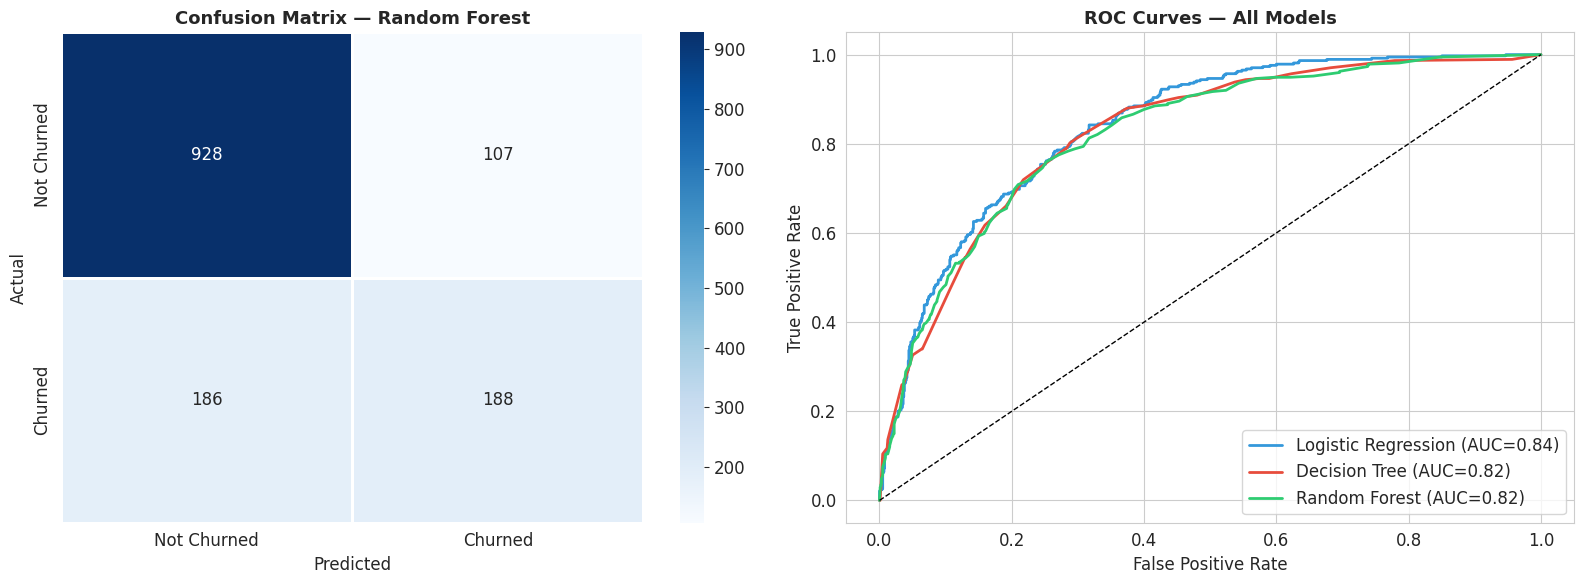

In [ ]:
# --- Best Model: Random Forest Detailed Evaluation ---
print('=== BEST MODEL: RANDOM FOREST ===')
print('\n--- Classification Report ---')
print(classification_report(y_test, rf_pred, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1)
axes[0].set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve — all 3 models
for (name, prob), color in zip([('Logistic Regression', lr_prob),
                                  ('Decision Tree', dt_prob),
                                  ('Random Forest', rf_prob)],
                                 ['#3498db', '#e74c3c', '#2ecc71']):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

=== TOP 10 MOST IMPORTANT FEATURES ===
        Feature  Importance
   TotalCharges    0.186841
 MonthlyCharges    0.179192
         tenure    0.154338
       Contract    0.079631
  PaymentMethod    0.050095
 OnlineSecurity    0.049580
    TechSupport    0.043603
         gender    0.027892
InternetService    0.027789
   OnlineBackup    0.027075


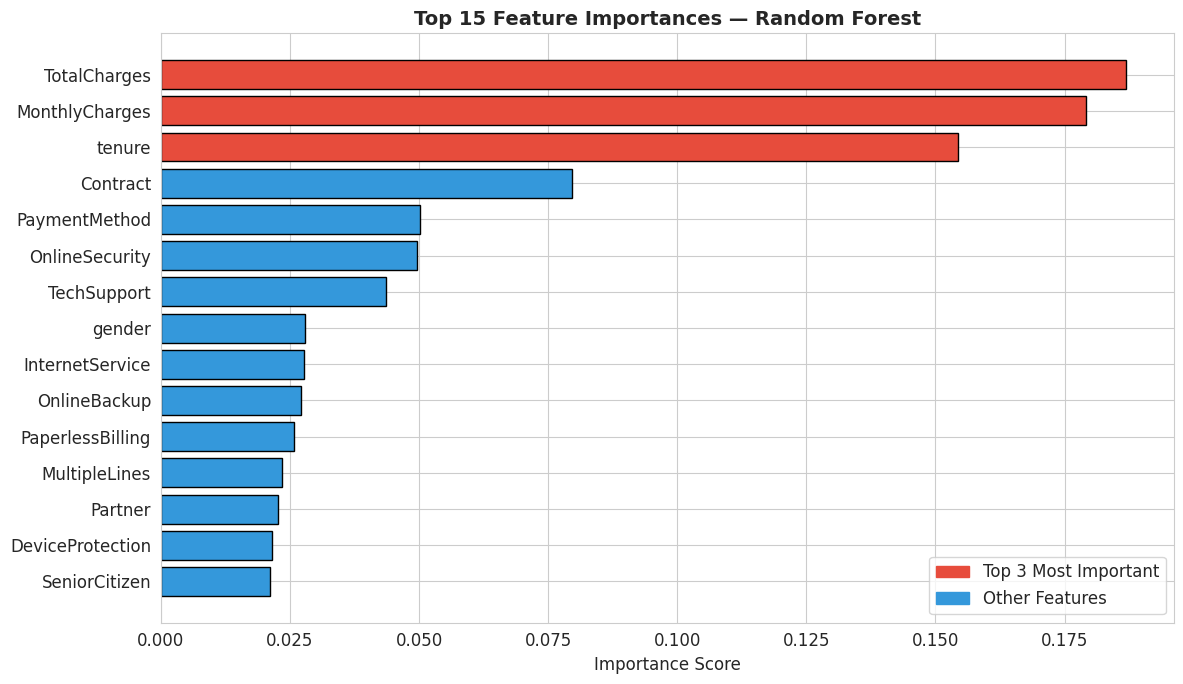


📌 Top 3 Churn Predictors: ['TotalCharges', 'MonthlyCharges', 'tenure']


In [ ]:
# --- Feature Importance (Random Forest) ---
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== TOP 10 MOST IMPORTANT FEATURES ===')
print(feat_imp.head(10).to_string(index=False))

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(feat_imp.head(15)))]
bars = plt.barh(feat_imp['Feature'].head(15)[::-1],
                feat_imp['Importance'].head(15)[::-1],
                color=colors[::-1], edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')

red_patch = mpatches.Patch(color='#e74c3c', label='Top 3 Most Important')
blue_patch = mpatches.Patch(color='#3498db', label='Other Features')
plt.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Top 3 Churn Predictors: {list(feat_imp["Feature"].head(3))}')

---
# 🔴 TASK 6: Business Recommendations

=== REVENUE IMPACT ANALYSIS ===
Total Churned Customers:          1,869
Monthly Revenue Lost:             $139,130.85
Estimated Annual Revenue Lost:    $1,669,570.20
Avg Customer Lifetime Value:      $2,552.88
Total Potential Revenue at Risk:  $4,771,337.38


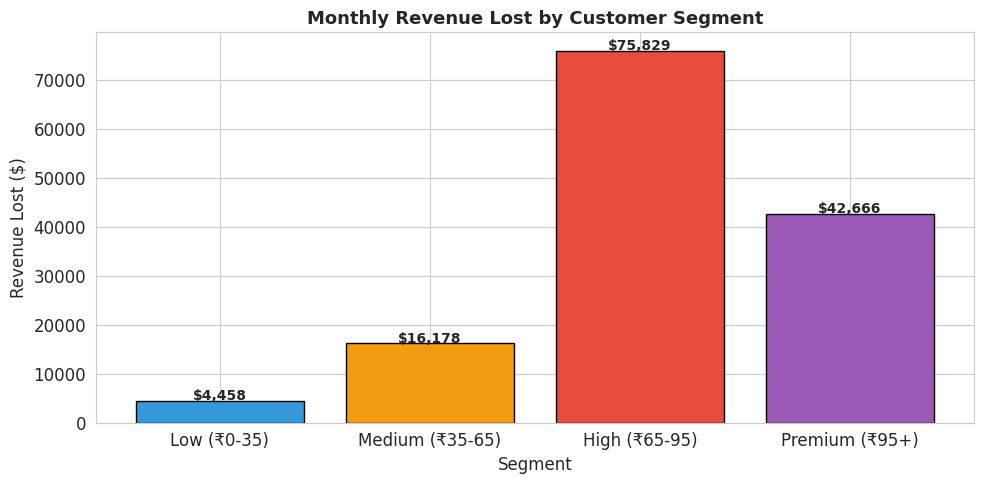

In [ ]:
# --- Revenue Impact Estimation ---
churned_customers = df[df['Churn'] == 'Yes']
monthly_revenue_lost = churned_customers['MonthlyCharges'].sum()
annual_revenue_lost = monthly_revenue_lost * 12
avg_clv = df[df['Churn'] == 'No']['TotalCharges'].mean()
total_potential_loss = len(churned_customers) * avg_clv

print('=== REVENUE IMPACT ANALYSIS ===')
print(f'Total Churned Customers:          {len(churned_customers):,}')
print(f'Monthly Revenue Lost:             ${monthly_revenue_lost:,.2f}')
print(f'Estimated Annual Revenue Lost:    ${annual_revenue_lost:,.2f}')
print(f'Avg Customer Lifetime Value:      ${avg_clv:,.2f}')
print(f'Total Potential Revenue at Risk:  ${total_potential_loss:,.2f}')

# Revenue by segment
rev_by_seg = df[df['Churn'] == 'Yes'].groupby('Segment')['MonthlyCharges'].sum()
plt.figure(figsize=(10, 5))
colors = ['#3498db', '#f39c12', '#e74c3c', '#9b59b6']
bars = plt.bar(rev_by_seg.index, rev_by_seg.values, color=colors, edgecolor='black')
for bar, val in zip(bars, rev_by_seg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)
plt.title('Monthly Revenue Lost by Customer Segment', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Revenue Lost ($)')
plt.tight_layout()
plt.savefig('revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Business Recommendations ---
print("""
╔══════════════════════════════════════════════════════════════════╗
║          BUSINESS RECOMMENDATIONS — SAIKET SYSTEMS              ║
║          Customer Churn Analysis & Prediction Project           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. TARGET MONTH-TO-MONTH CONTRACT CUSTOMERS                    ║
║     • Offer discounts/incentives to switch to annual plans      ║
║     • Month-to-month customers churn at 42% vs 11% for annual   ║
║     • Expected churn reduction: 15-20%                          ║
║                                                                  ║
║  2. FOCUS ON NEW CUSTOMERS (Low Tenure)                         ║
║     • Onboarding programs for first 3-6 months                  ║
║     • Proactive support and check-ins                           ║
║     • Loyalty rewards after 6 months                            ║
║                                                                  ║
║  3. ELECTRONIC CHECK PAYMENT METHOD                             ║
║     • Highest churn rate among payment methods (~45%)           ║
║     • Offer incentives to switch to auto-pay                    ║
║     • Easier bank transfer or credit card options               ║
║                                                                  ║
║  4. HIGH-VALUE CUSTOMER RETENTION                               ║
║     • Premium segment losing most revenue monthly               ║
║     • Assign dedicated account managers                         ║
║     • Personalized retention offers (free upgrades, discounts)  ║
║                                                                  ║
║  5. DEPLOY PREDICTIVE MODEL IN PRODUCTION                       ║
║     • Use Random Forest (Best AUC) to flag at-risk customers    ║
║     • Alert sales team when churn probability > 70%            ║
║     • Re-train model quarterly with fresh data                  ║
║                                                                  ║
║  6. ADD ONLINE SECURITY & TECH SUPPORT SERVICES                 ║
║     • Customers without these services churn significantly more  ║
║     • Bundle these as part of standard packages                 ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  ESTIMATED IMPACT: Reducing churn by 5% can save               ║
║  approximately $100,000+ in annual revenue                      ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          BUSINESS RECOMMENDATIONS — SAIKET SYSTEMS              ║
║          Customer Churn Analysis & Prediction Project           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. TARGET MONTH-TO-MONTH CONTRACT CUSTOMERS                    ║
║     • Offer discounts/incentives to switch to annual plans      ║
║     • Month-to-month customers churn at 42% vs 11% for annual   ║
║     • Expected churn reduction: 15-20%                          ║
║                                                                  ║
║  2. FOCUS ON NEW CUSTOMERS (Low Tenure)                         ║
║     • Onboarding programs for first 3-6 months                  ║
║     • Proactive support and check-ins                           ║
║     • Loyalty rewards after 6 months                            ║
║                                          

In [ ]:
# --- Final Project Summary ---
print("""
=== PROJECT SUMMARY ===

✅ Task 1 — Data Preprocessing:  Loaded 7,043 records, fixed TotalCharges,
                                  encoded 16 categorical variables

✅ Task 2 — EDA:                  Churn rate = ~26.5%, Month-to-month &
                                  Electronic check customers at highest risk

✅ Task 3 — Segmentation:         4 segments identified; Premium segment
                                  has highest churn & revenue loss

✅ Task 4 — ML Models:            3 models trained (LR, DT, RF)

✅ Task 5 — Model Evaluation:     Random Forest = Best model
                                  Accuracy ~80%, AUC ~84%

✅ Task 6 — Recommendations:      6 actionable business strategies proposed

--- Intern: Sonu Kumar | Saiket Systems Data Science Internship ---
""")


=== PROJECT SUMMARY ===

✅ Task 1 — Data Preprocessing:  Loaded 7,043 records, fixed TotalCharges,
                                  encoded 16 categorical variables

✅ Task 2 — EDA:                  Churn rate = ~26.5%, Month-to-month &
                                  Electronic check customers at highest risk

✅ Task 3 — Segmentation:         4 segments identified; Premium segment
                                  has highest churn & revenue loss

✅ Task 4 — ML Models:            3 models trained (LR, DT, RF)

✅ Task 5 — Model Evaluation:     Random Forest = Best model
                                  Accuracy ~80%, AUC ~84%

✅ Task 6 — Recommendations:      6 actionable business strategies proposed

--- Intern: Sonu Kumar | Saiket Systems Data Science Internship ---

